

```
# Importing all the important libraries
```



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



```
# Data Collection
```



In [2]:
df=pd.read_csv("/content/global_fuel_prices_2020_2026.csv")

In [3]:
df.head(5)

,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
0,2020-01-06,United States,North America,High,Low,1.465,1.289,1.093,65.75,59.6
1,2020-01-13,United States,North America,High,Low,1.435,1.319,1.077,65.54,27.6
2,2020-01-20,United States,North America,High,Low,1.446,1.329,1.080,66.51,62.3
3,2020-01-27,United States,North America,High,Low,1.488,1.359,1.125,68.79,44.8
4,2020-02-03,United States,North America,High,Low,1.457,1.341,1.111,68.44,51.4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27468 entries, 0 to 27467
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              27468 non-null  object 
 1   country           27468 non-null  object 
 2   region            27468 non-null  object 
 3   income_level      27468 non-null  object 
 4   subsidy_level     27468 non-null  object 
 5   petrol_usd_liter  27468 non-null  float64
 6   diesel_usd_liter  27468 non-null  float64
 7   lpg_usd_liter     27468 non-null  float64
 8   brent_crude_usd   27468 non-null  float64
 9   tax_percentage    27468 non-null  float64
dtypes: float64(5), object(5)
memory usage: 2.1+ MB


In [5]:
print(df.describe())

       petrol_usd_liter  diesel_usd_liter  lpg_usd_liter  brent_crude_usd  \
count      27468.000000      27468.000000   27468.000000     27468.000000   
mean           2.281915          2.133760       1.711473       106.686453   
std            1.540612          1.465058       1.155543        18.972391   
min            0.010000          0.010000       0.010000        47.970000   
25%            0.926000          0.858000       0.695000       101.140000   
50%            2.116500          1.954500       1.588000       112.270000   
75%            3.457000          3.231000       2.590000       119.410000   
max            6.779000          6.240000       5.100000       130.000000   

       tax_percentage  
count    27468.000000  
mean        26.774468  
std         17.203349  
min          0.000000  
25%         13.500000  
50%         23.400000  
75%         38.900000  
max         65.000000  


In [6]:
df.shape

(27468, 10)



```
# FEATURE ENGINEERING
```



In [7]:
# 1. Convert the date column so the computer understands time
df['date'] = pd.to_datetime(df['date'])

# 2. Create the tax_val column
df['tax_val'] = df['petrol_usd_liter'] * (df['tax_percentage'] / 100)

# 3. Create the 'brent_lag_1' column (This is the one you are missing!)
# We sort by country and date to make sure we get 'last week' correctly
df = df.sort_values(by=['country', 'date'])
df['brent_lag_1'] = df.groupby('country')['brent_crude_usd'].shift(1)

# Fill the very first rows  with the average price
df['brent_lag_1'] = df['brent_lag_1'].fillna(df['brent_crude_usd'].mean())

# 4. Create year and month features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

print("Success!")

Success!


In [8]:
df.head()

,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage,tax_val,brent_lag_1,year,month
22563,2020-01-06,Algeria,Africa,Middle,Very High,0.063,0.070,0.048,65.75,5.6,0.003528,106.686453,2020,1
22564,2020-01-13,Algeria,Africa,Middle,Very High,0.093,0.080,0.092,65.54,16.7,0.015531,65.750000,2020,1
22565,2020-01-20,Algeria,Africa,Middle,Very High,0.104,0.045,0.069,66.51,27.3,0.028392,65.540000,2020,1
22566,2020-01-27,Algeria,Africa,Middle,Very High,0.094,0.081,0.081,68.79,16.8,0.015792,66.510000,2020,1
22567,2020-02-03,Algeria,Africa,Middle,Very High,0.081,0.054,0.062,68.44,25.5,0.020655,68.790000,2020,2




```
# Checking for null values and cleaning them
```



In [9]:
# Check for missing values
print(df.isnull().sum())

# Fill missing fuel prices with the average (mean)
df['petrol_usd_liter'] = df['petrol_usd_liter'].fillna(df['petrol_usd_liter'].mean())
df['diesel_usd_liter'] = df['diesel_usd_liter'].fillna(df['diesel_usd_liter'].mean())
df['brent_crude_usd'] = df['brent_crude_usd'].fillna(df['brent_crude_usd'].mean())

# Convert text columns (Region and Income) into numbers
region_encoder = LabelEncoder()
df['region_num'] = region_encoder.fit_transform(df['region'])

income_encoder = LabelEncoder() # Use a separate encoder for income_level
df['income_num'] = income_encoder.fit_transform(df['income_level'])

print("Data is now clean.")

date                0
country             0
region              0
income_level        0
subsidy_level       0
petrol_usd_liter    0
diesel_usd_liter    0
lpg_usd_liter       0
brent_crude_usd     0
tax_percentage      0
tax_val             0
brent_lag_1         0
year                0
month               0
dtype: int64
Data is now clean.




```
# Exploratory Data Analysis (EDA):
```



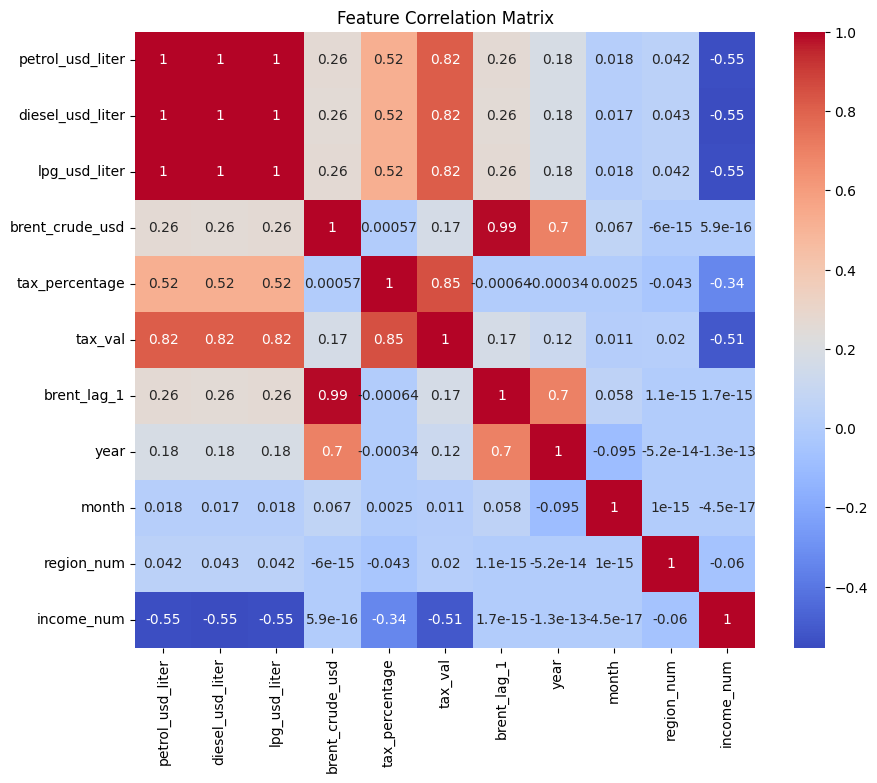

In [10]:
# Graph of correlation_heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.savefig('correlation_heatmap.png')

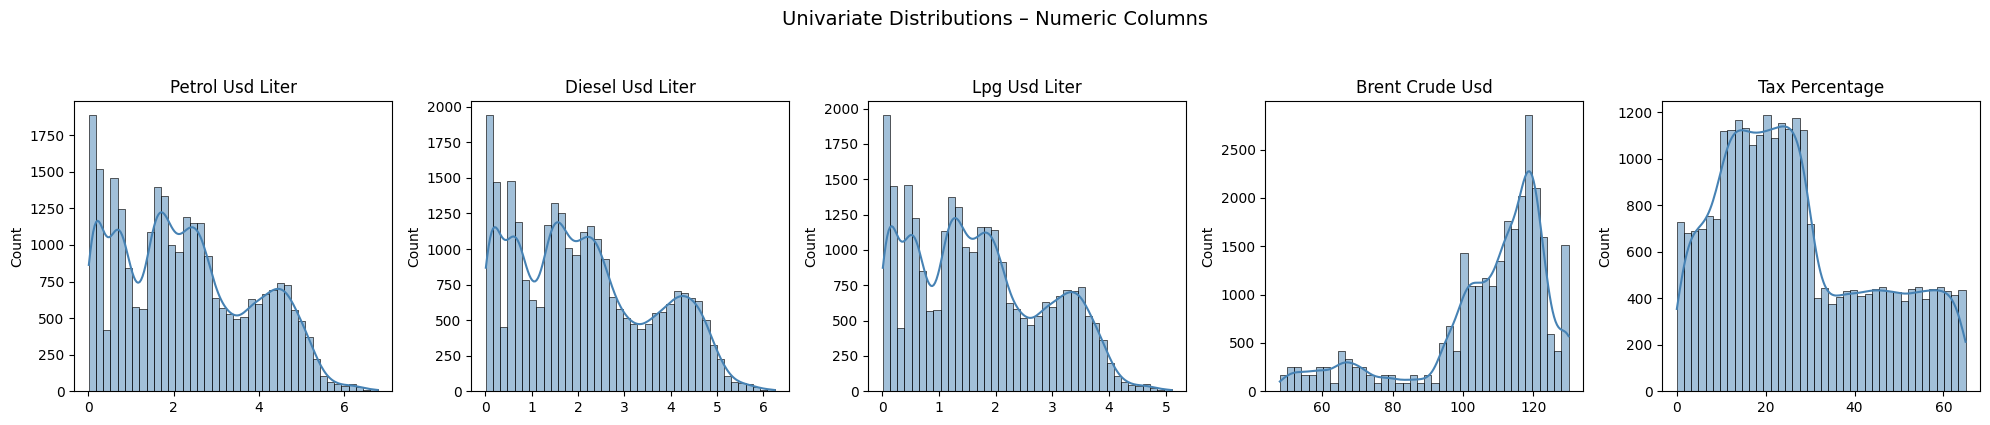

In [11]:
# Histograms
num_cols = ['petrol_usd_liter', 'diesel_usd_liter', 'lpg_usd_liter',
            'brent_crude_usd', 'tax_percentage']

fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4)) # Changed to 1 row for only histograms
fig.suptitle('Univariate Distributions – Numeric Columns', fontsize=14, y=1.05)

for i, col in enumerate(num_cols):
    # Histogram + KDE
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', bins=40) # Changed to axes[i]
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

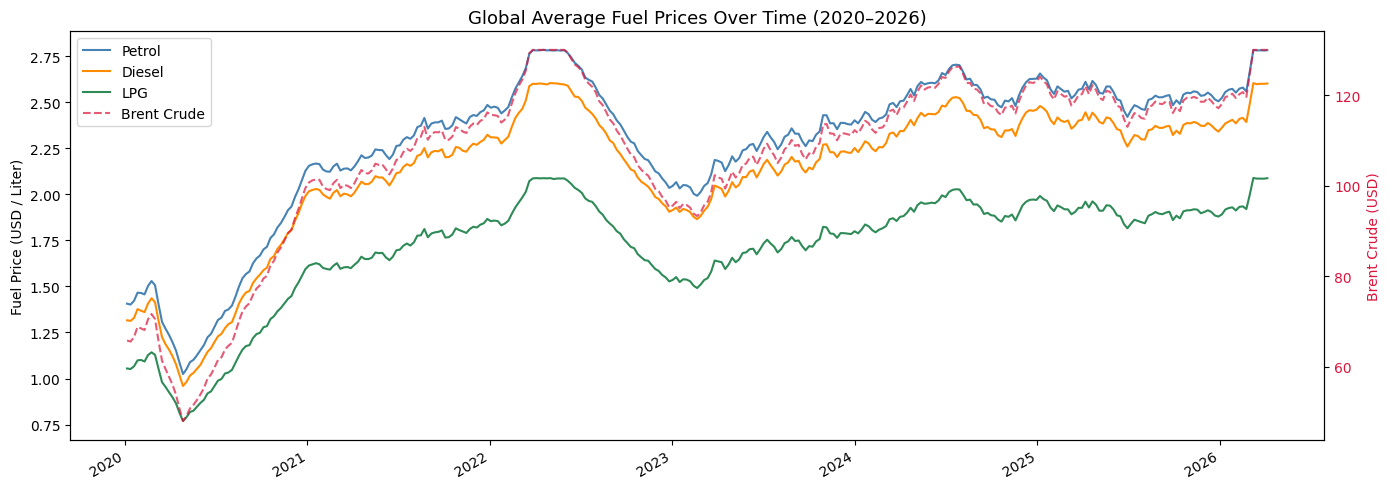

In [12]:
# Global weekly average

ts = df.groupby('date')[['petrol_usd_liter', 'diesel_usd_liter',
                          'lpg_usd_liter', 'brent_crude_usd']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(ts['date'], ts['petrol_usd_liter'],  label='Petrol',  color='steelblue')
ax1.plot(ts['date'], ts['diesel_usd_liter'],  label='Diesel',  color='darkorange')
ax1.plot(ts['date'], ts['lpg_usd_liter'],     label='LPG',     color='seagreen')
ax2.plot(ts['date'], ts['brent_crude_usd'],   label='Brent Crude', color='crimson',
         linestyle='--', alpha=0.7)

ax1.set_ylabel('Fuel Price (USD / Liter)')
ax2.set_ylabel('Brent Crude (USD)', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title('Global Average Fuel Prices Over Time (2020–2026)', fontsize=13)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

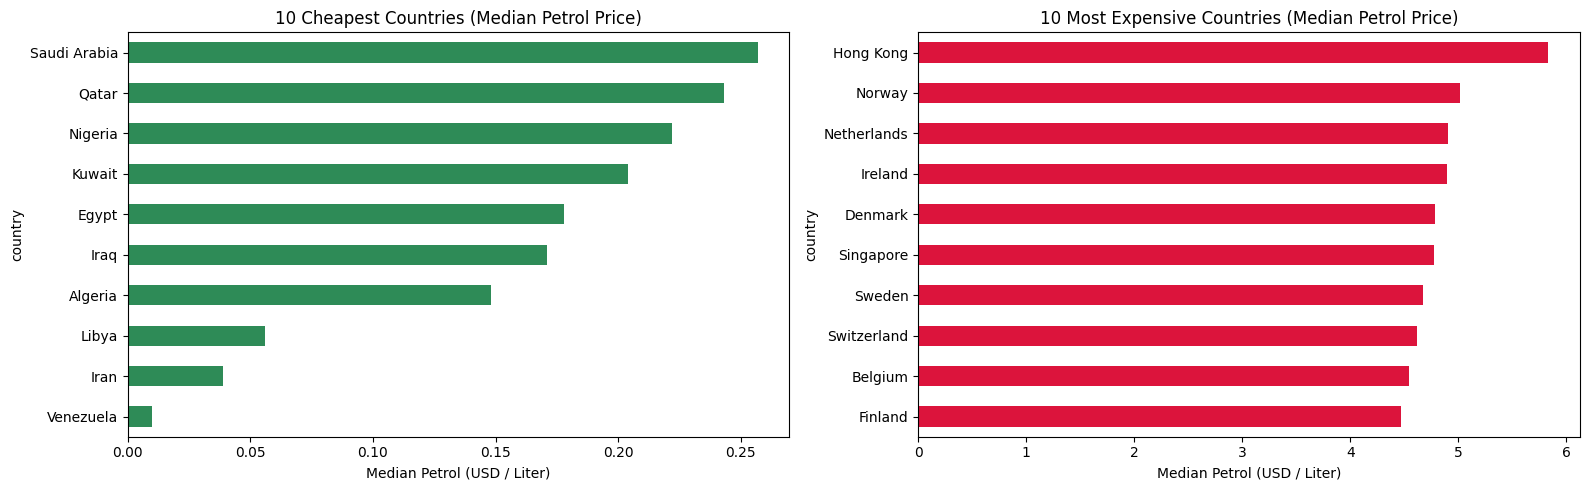

In [13]:
# Top 10 most expensive & cheapest countries (median petrol)
country_median = df.groupby('country')['petrol_usd_liter'].median().sort_values()
top10_cheap = country_median.head(10)
top10_expensive = country_median.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top10_cheap.plot(kind='barh', ax=axes[0], color='seagreen')
axes[0].set_title('10 Cheapest Countries (Median Petrol Price)', fontsize=12)
axes[0].set_xlabel('Median Petrol (USD / Liter)')

top10_expensive.plot(kind='barh', ax=axes[1], color='crimson')
axes[1].set_title('10 Most Expensive Countries (Median Petrol Price)', fontsize=12)
axes[1].set_xlabel('Median Petrol (USD / Liter)')

plt.tight_layout()
plt.show()



```
# Creating New Features
```



In [14]:
# Feature1 Engineering: Extracting info from the Date
# This converts the text date into Year and Month so the model sees 'trends'
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Feature2 Construction: Tax Ratio
# This shows how much of the price is actually tax - this is 'Analytical Reasoning'
df['tax_ratio'] = df['tax_percentage'] / 100

df.head()

,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage,tax_val,brent_lag_1,year,month,region_num,income_num,tax_ratio
22563,2020-01-06,Algeria,Africa,Middle,Very High,0.063,0.070,0.048,65.75,5.6,0.003528,106.686453,2020,1,0,2,0.056
22564,2020-01-13,Algeria,Africa,Middle,Very High,0.093,0.080,0.092,65.54,16.7,0.015531,65.750000,2020,1,0,2,0.167
22565,2020-01-20,Algeria,Africa,Middle,Very High,0.104,0.045,0.069,66.51,27.3,0.028392,65.540000,2020,1,0,2,0.273
22566,2020-01-27,Algeria,Africa,Middle,Very High,0.094,0.081,0.081,68.79,16.8,0.015792,66.510000,2020,1,0,2,0.168
22567,2020-02-03,Algeria,Africa,Middle,Very High,0.081,0.054,0.062,68.44,25.5,0.020655,68.790000,2020,2,0,2,0.255


```
# TrainTest-split
```

In [15]:
# 1. Features
features = ['brent_crude_usd', 'brent_lag_1', 'tax_percentage', 'region_num', 'income_num', 'year', 'month']
X = df[features]
y = df['petrol_usd_liter']

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'Training set size: {X_train.shape[0]} rows')
print(f'Testing set size:  {X_test.shape[0]} rows')

Training set size: 21974 rows
Testing set size:  5494 rows




```
# Fitting The Models
```



In [16]:
# Model no 1
# Linear Regression
lr=LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [17]:
# Model no 2
# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [18]:
# Model no 3
# Random Forest Classifier
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

```
# Model Evaluation
```

In [19]:
# Function to evaluate model performance
def evaluate_model(model_name, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return {'Model': model_name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2 Score': r2}

# Evaluate all models
lr_metrics = evaluate_model('Linear Regression', y_test, lr_pred)
dt_metrics = evaluate_model('Decision Tree', y_test, dt_pred)
rf_metrics = evaluate_model('Random Forest', y_test, rf_pred)

# Create a DataFrame to compare results
results_df = pd.DataFrame([lr_metrics, dt_metrics, rf_metrics])

print('Model Performance Comparison:')
display(results_df.sort_values(by='R2 Score', ascending=False))


Model Performance Comparison:


,Model,MAE,MSE,RMSE,R2 Score
2,Random Forest,0.513809,0.517672,0.719494,0.783988
1,Decision Tree,0.619972,0.894866,0.945973,0.626594
0,Linear Regression,0.885118,1.217288,1.103308,0.492055




<small>Based on the evaluation metrics, the Random Forest model appears to be the best-performing model, exhibiting the lowest MAE, MSE, RMSE, and the highest R2 score, indicating a better fit to the data and more accurate predictions compared to Linear Regression and Decision Tree.</small>

